#Testbench Setup -> Generate ocean script "ocean_script_NMOS4.txt" -> Export transpose reults in .csv  
Save no result, no netlist, just need the export to generate a .csv file, run in Ocean script => No Interface lag  
See ocean_script_NMOS4.txt for exemple of ocean script used for generation  
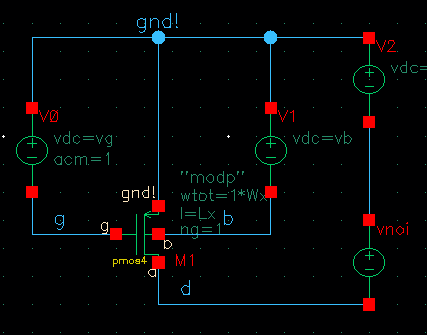 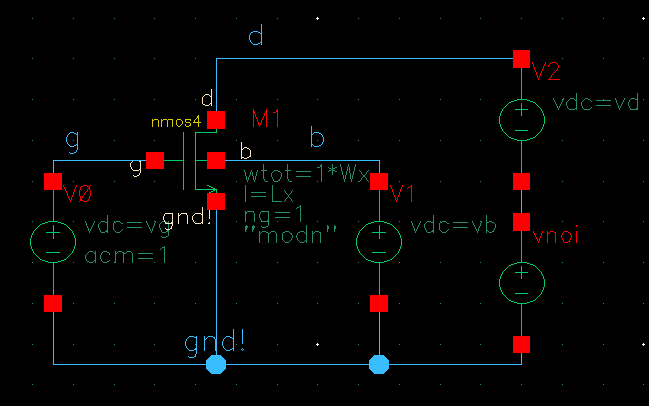 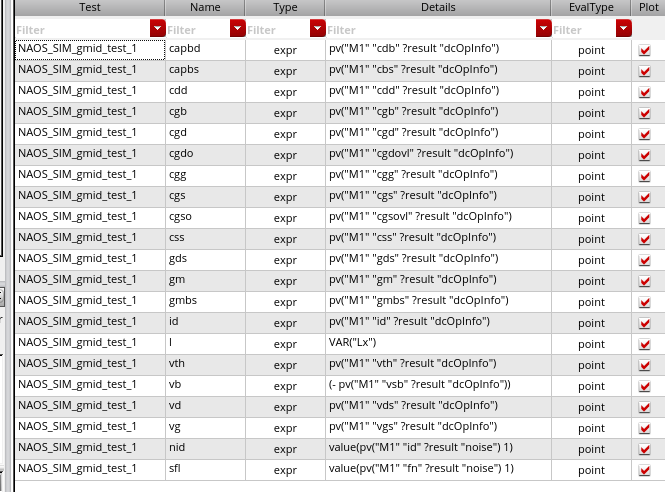


In [1]:
import pandas as pd
import numpy as np
#from numpy.core.records import fromarrays
from numpy.rec import fromarrays  # Updated to use the public API
from scipy.io import savemat

In [2]:

choice = 0  #start from 0
#devices = ['nfet_01v8_lvt', 'nfet_01v8', 'pfet_01v8_lvt', 'pfet_01v8']
devices = ['nmos4']
# widths used for characterization and fringe cap parameters (fringe caps are not included in ngspice output)
w = np.array([5.0])
nfing = np.array([1])

In [ ]:
df_raw = pd.read_csv('../lookup_table/gmid_long_nmos4.txt')
df = df_raw
df = df_raw.drop(df.columns[:7], axis=1)
#df = df.drop(['vd.1', 'vg.1'], axis=1)
df.columns = df.columns.str.replace('.1', '')
df.columns = df.columns.str.replace('sfl', 'n1overf')
df = df.apply(pd.to_numeric)
df.info()
df=abs(df)

In [ ]:
df

In [ ]:
# sweep variable vectors
l =   np.unique(df['l'])*1e6
vgs = np.unique(df['vg'])
vds = np.unique(df['vd'])
vsb = np.unique(df['vb'])
# dimensions
nL = len(l)
nVSB = len(vsb)
nVDS = len(vds)
nVGS = len(vgs)

# reshape selon l'ordre du sweep ngspice : L, VSB, VDS, VGS
shape_ngspice = (nL, nVSB, nVDS, nVGS)

def reshape_param(name):
    arr = np.reshape(df[name].values, shape_ngspice)
    # reorder vers l'ordre pygmid : L, VGS, VDS, VSB
    arr = np.transpose(arr, (0,3,2,1))
    return arr

id  = reshape_param('id')
vt  = reshape_param('vth')
gm  = reshape_param('gm')
gmb = reshape_param('gmbs')
gds = reshape_param('gds')
cgg = reshape_param('cgg') + reshape_param('cgdo') + reshape_param('cgso')
cgb = reshape_param('cgb')
cgd = reshape_param('cgd') + reshape_param('cgdo')
cgs = reshape_param('cgs') + reshape_param('cgso')
cdd = reshape_param('cdd') + reshape_param('capbd') + reshape_param('cgdo')
css = reshape_param('css') + reshape_param('capbs') + reshape_param('cgso')
sth = reshape_param('nid')**2
sfl = reshape_param('n1overf')**2


In [ ]:
dic = {
  "INFO": "SkyWater, 130nm CMOS, BSIM4",
  "CORNER": "NOM",
  "TEMP": 300.0,
  "VGS": vgs,
  "VDS": vds,
  "VSB": vsb,
  "L": l,
  "W": w[choice],
  "NFING": nfing[choice],
  "ID": id,
  "VT": vt,
  "GM": gm,
  "GMB": gmb,
  "GDS": gds,
  "CGG": cgg,
  "CGB": cgb,
  "CGD": cgd,
  "CGS": cgs,
  "CDD": cdd,
  "CSS": css,
  "STH": sth,
  "SFL": sfl
}
#savemat('./simulation/'+devices[choice]+'.mat', {devices[choice]: dic})
savemat('../lookup_table/nmos4.mat', {'nmos4': dic})

In [ ]:
import numpy as np
import scipy.constants as sc
import matplotlib.pyplot as plt
from pygmid import Lookup as lk


In [ ]:
fet = lk('../lookup_table/nmos4.mat')

In [ ]:
# sweep variable vectors
l = fet['L']
vgs = fet['VGS']
vds = fet['VDS']
vsb = fet['VSB']

In [ ]:
fet.lookup('id', L=2, VDS=1.35, VGS=1.35, VSB=0.1)

In [ ]:
fet.lookup('id', L=2, VDS=1.35, VGS=1.35, VSB=0.0)

In [ ]:
# plot gm/ID and fT versus gate bias
L1 = min(l); VDS1=1.35; VSB1=0
gm_id1 = fet.lookup('GM_ID', L=L1, VDS=VDS1, VSB=VSB1)
ft1 = fet.lookup('GM_CGG', L=L1, VDS=VDS1, VSB=VSB1)/2/np.pi
vt = fet.lookup('VT', L=L1, VGS=0.9, VDS=VDS1, VSB=VSB1)

fig, ax1 = plt.subplots()
ax1.grid(axis='x')
ax1.set_xlabel('$V_{GS}$ (V)')
color = 'tab:blue'
ax1.set_ylabel('$g_m/I_D$ (S/A)', color=color)
ax1.plot(vgs, gm_id1, color=color, marker='*')
ax1.tick_params(axis='y', labelcolor=color)
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('$f_T$ (GHz)', color=color)
ax2.plot(vgs, ft1/1e9, color=color, marker='*')
ax2.tick_params(axis='y', labelcolor=color)
fig.tight_layout()
plt.title(devices[choice]+', $L$='+str(L1)+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.xlim(0, 2.7)
plt.axvline(x=vt, color='k', linestyle='--')
plt.show()

In [ ]:
# plot gamma versus gm/ID for all L
gamma = fet.lookup('STH_GM', L=l, VDS=VDS1, VSB=VSB1) / (4*sc.Boltzmann*300)

fig, ax = plt.subplots()
ax.plot(gm_id1.transpose(), gamma.transpose())
ax.legend(loc='center right', bbox_to_anchor=(1.2, 0.5), title='L', labels=l.tolist())
plt.xlim(3, 20)
plt.ylim(0, 4)
plt.xlabel('$g_m/I_D$ (S/A)')
plt.ylabel(r'Thermal noise $\gamma$ factor')
plt.grid(which='minor')
plt.grid(which='major')
plt.title(devices[choice]+', $V_{DS}$='+str(VDS1)+', $V_{SB}$='+str(VSB1))
plt.show()